## 1. Load Libraries

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

c:\Users\andre\anaconda3\envs\python-cpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [47]:
import missingno as msno
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Load Data

In [3]:
file_path = 'gym_members_dataset.csv'

In [4]:
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "hassaan2580/churn-prediction-gym-members-dataset",
    file_path
)

## 3. Pre-processing

### 3.1. Preliminary Data Check

In [5]:
df.head()

,Member_ID,Name,Age,Gender,Address,Phone_Number,Membership_Type,Join_Date,Last_Visit_Date,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn
0,1,NaN,19.0,Male,"Street 171, City 39",032-51510359,Quarterly,2022-07-23,2022-11-03,Pull-ups,93,214.0,13995.0,18.0,No
1,2,Shanza,19.0,Female,"Street 111, City 18",039-19243328,Monthly,2023-12-04,2024-02-14,Squats,37,436.0,4612.0,11.0,No
2,3,Ubaidullah,52.0,Male,"Street 69, City 21",033-60221501,Quarterly,2024-09-13,2024-12-07,Bench Press,98,523.0,3124.0,4.0,Yes
3,4,Mansoor Ahmed,52.0,Male,"Street 72, City 39",035-55527902,Monthly,2024-06-05,2025-02-24,Pull-ups,66,282.0,4586.0,24.0,No
4,5,Hanzala,32.0,Male,"Street 6, City 12",038-93946322,Monthly,2022-06-15,2022-12-02,Bench Press,32,522.0,16353.0,18.0,No


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Member_ID                 150 non-null    int64  
 1   Name                      127 non-null    object 
 2   Age                       137 non-null    float64
 3   Gender                    150 non-null    object 
 4   Address                   150 non-null    object 
 5   Phone_Number              150 non-null    object 
 6   Membership_Type           150 non-null    object 
 7   Join_Date                 141 non-null    object 
 8   Last_Visit_Date           150 non-null    object 
 9   Favorite_Exercise         150 non-null    object 
 10  Avg_Workout_Duration_Min  150 non-null    int64  
 11  Avg_Calories_Burned       139 non-null    float64
 12  Total_Weight_Lifted_kg    142 non-null    float64
 13  Visits_Per_Month          138 non-null    float64
 14  Churn     

In [7]:
df.isna().sum()

Member_ID                    0
Name                        23
Age                         13
Gender                       0
Address                      0
Phone_Number                 0
Membership_Type              0
Join_Date                    9
Last_Visit_Date              0
Favorite_Exercise            0
Avg_Workout_Duration_Min     0
Avg_Calories_Burned         11
Total_Weight_Lifted_kg       8
Visits_Per_Month            12
Churn                        0
dtype: int64

In [8]:
missing_percentage = (df.isna().sum() / len(df)) * 100

In [9]:
missing_percentage

Member_ID                    0.000000
Name                        15.333333
Age                          8.666667
Gender                       0.000000
Address                      0.000000
Phone_Number                 0.000000
Membership_Type              0.000000
Join_Date                    6.000000
Last_Visit_Date              0.000000
Favorite_Exercise            0.000000
Avg_Workout_Duration_Min     0.000000
Avg_Calories_Burned          7.333333
Total_Weight_Lifted_kg       5.333333
Visits_Per_Month             8.000000
Churn                        0.000000
dtype: float64

In [10]:
print(missing_percentage)

Member_ID                    0.000000
Name                        15.333333
Age                          8.666667
Gender                       0.000000
Address                      0.000000
Phone_Number                 0.000000
Membership_Type              0.000000
Join_Date                    6.000000
Last_Visit_Date              0.000000
Favorite_Exercise            0.000000
Avg_Workout_Duration_Min     0.000000
Avg_Calories_Burned          7.333333
Total_Weight_Lifted_kg       5.333333
Visits_Per_Month             8.000000
Churn                        0.000000
dtype: float64


In [11]:
missing_columns = missing_percentage[missing_percentage > 0].index.tolist()
missing_columns

['Name',
 'Age',
 'Join_Date',
 'Avg_Calories_Burned',
 'Total_Weight_Lifted_kg',
 'Visits_Per_Month']

In [12]:
df_missing_rows = df[df[missing_columns].isna().any(axis=1)]
df_missing_rows

,Member_ID,Name,Age,Gender,Address,Phone_Number,Membership_Type,Join_Date,Last_Visit_Date,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn
0,1,NaN,19.0,Male,"Street 171, City 39",032-51510359,Quarterly,2022-07-23,2022-11-03,Pull-ups,93,214.0,13995.0,18.0,No
6,7,Kumail,46.0,Male,"Street 35, City 1",039-95163386,Monthly,2023-05-14,2023-07-10,Squats,33,NaN,4926.0,7.0,Yes
9,10,Ayesha,NaN,Female,"Street 127, City 31",034-55245029,Monthly,2022-03-24,2022-06-26,Pull-ups,74,NaN,2113.0,19.0,No
10,11,Ammad,23.0,Male,"Street 165, City 47",035-72306131,Yearly,2022-06-09,2022-07-22,Bench Press,56,NaN,5978.0,11.0,No
14,15,Saeed Mchboob,27.0,Male,"Street 162, City 30",037-54758885,Monthly,2022-10-26,2023-01-16,Treadmill,31,NaN,7611.0,19.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,138,NaN,29.0,Male,"Street 6, City 35",031-80529451,Yearly,2024-08-31,2025-04-16,Pull-ups,74,502.0,8439.0,12.0,No
138,139,Zainab,24.0,Female,"Street 27, City 44",034-98999212,Yearly,2023-09-01,2024-01-12,Cycling,69,257.0,15952.0,NaN,No
140,141,NaN,27.0,Male,"Street 72, City 39",031-88717607,Monthly,2024-09-23,2025-04-08,Deadlift,86,274.0,2346.0,8.0,No
141,142,Tasneem,23.0,Female,"Street 61, City 38",038-39022969,Monthly,2022-11-24,2023-09-01,Bench Press,58,NaN,2224.0,21.0,No


In [13]:
df_missing_sorted = df_missing_rows.sort_values(by=missing_columns, ascending=True)
df_missing_sorted

,Member_ID,Name,Age,Gender,Address,Phone_Number,Membership_Type,Join_Date,Last_Visit_Date,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn
77,78,Adeena,NaN,Female,"Street 126, City 23",031-13205703,Monthly,2023-06-18,2023-10-03,Bench Press,61,632.0,1492.0,5.0,Yes
60,61,Afzal Hussain,46.0,Male,"Street 147, City 48",038-31542957,Quarterly,2024-08-03,2025-07-10,Squats,40,210.0,NaN,24.0,No
40,41,Ali Hamza,43.0,Male,"Street 72, City 44",036-72528490,Monthly,2023-08-28,2024-01-02,Pull-ups,58,767.0,NaN,19.0,No
10,11,Ammad,23.0,Male,"Street 165, City 47",035-72306131,Yearly,2022-06-09,2022-07-22,Bench Press,56,NaN,5978.0,11.0,No
9,10,Ayesha,NaN,Female,"Street 127, City 31",034-55245029,Monthly,2022-03-24,2022-06-26,Pull-ups,74,NaN,2113.0,19.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,77,NaN,49.0,Male,"Street 34, City 17",030-74120944,Quarterly,2023-01-14,2023-06-24,Squats,58,773.0,9917.0,12.0,No
39,40,NaN,51.0,Male,"Street 121, City 24",039-27958874,Monthly,2024-06-16,2025-01-11,Deadlift,89,261.0,12617.0,20.0,No
110,111,NaN,53.0,Male,"Street 24, City 42",036-63521451,Monthly,2024-06-21,2024-08-20,Pull-ups,35,706.0,8630.0,6.0,Yes
45,46,NaN,NaN,Male,"Street 168, City 49",034-34988026,Quarterly,2022-01-21,2022-08-13,Treadmill,74,209.0,NaN,6.0,Yes


<Axes: >

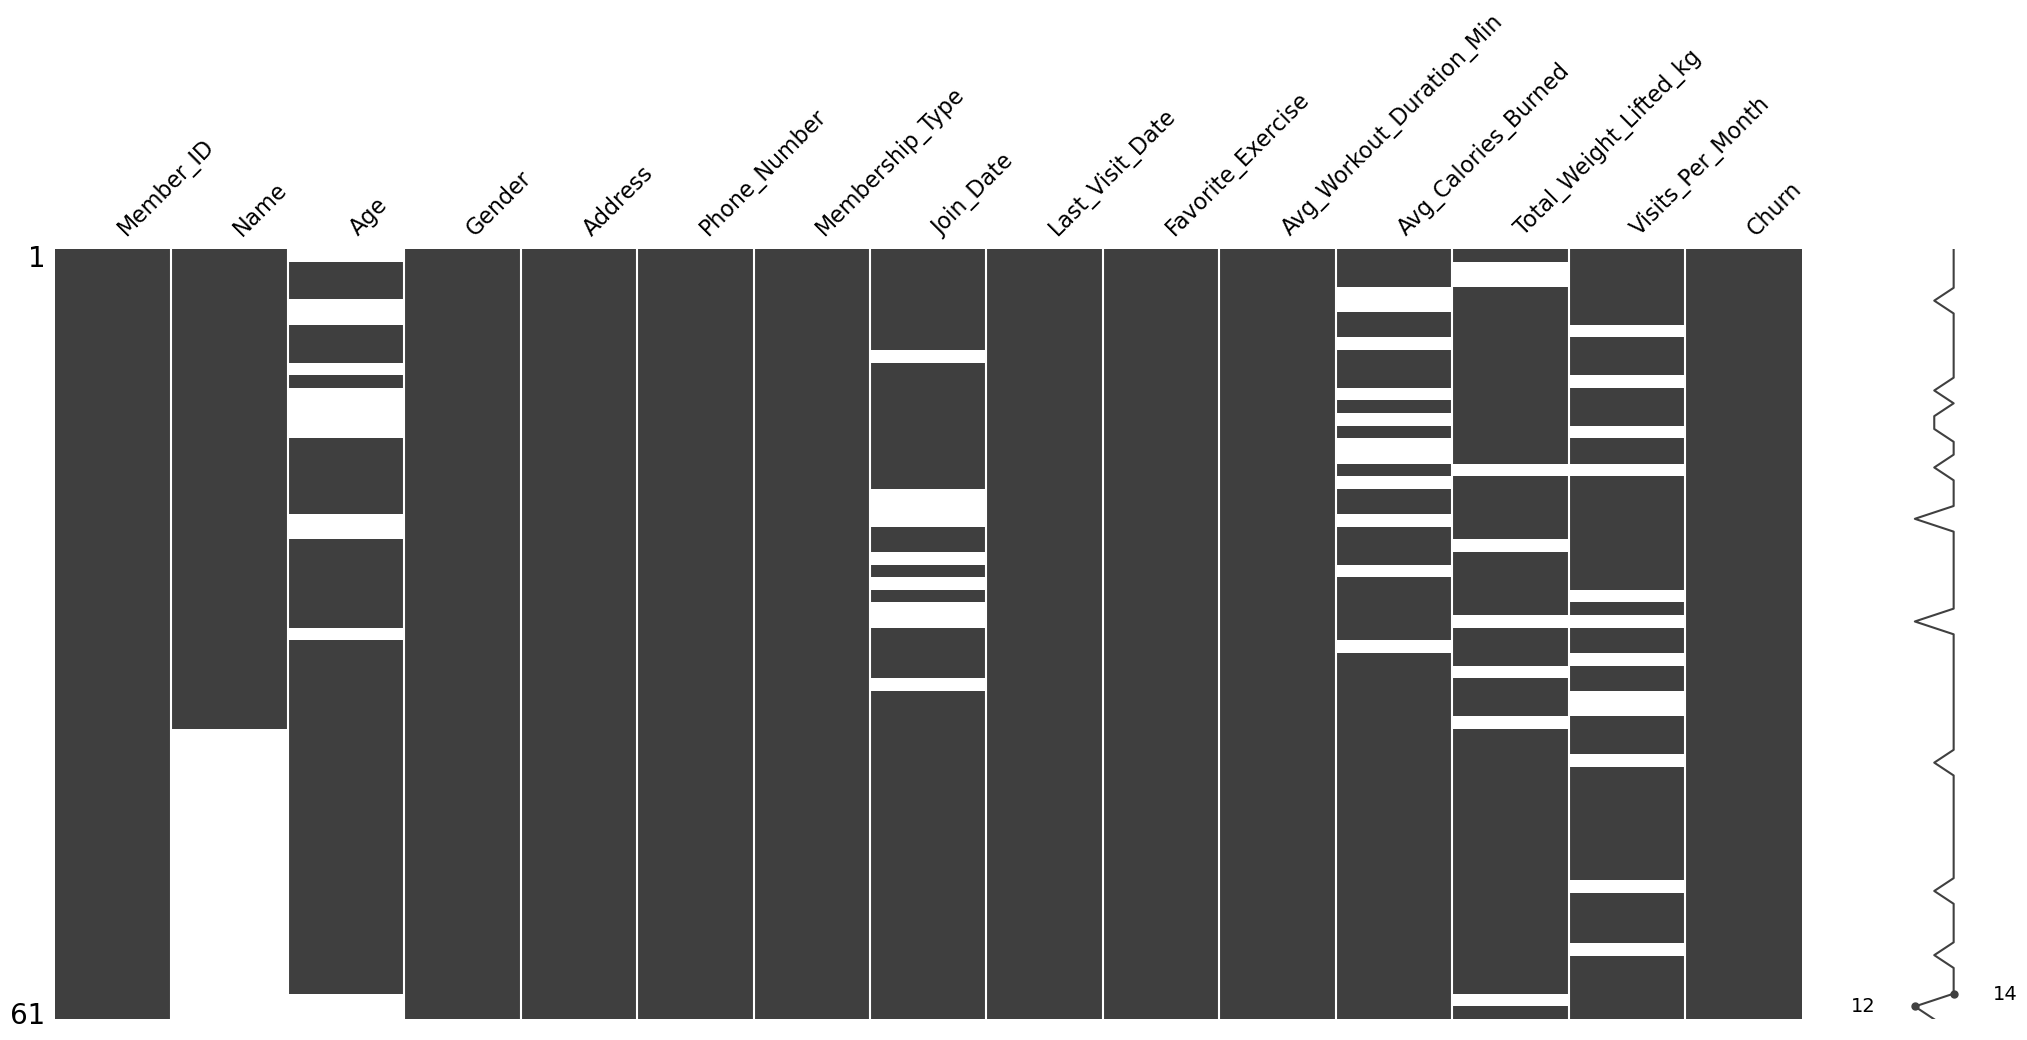

In [14]:
msno.matrix(df_missing_sorted)

The columns / features that contain missing values in the dataset are:
- `Name`
- `Age`
- `Join_Date`
- `Avg_Calories_Burned`
- `Total_Weight_Lifted_kg`
- `Visits_Per_Month`

Due to the relatively small amount of records in the dataset, and the quite numerous amount of null values, it is decided that there needs to be missing data handling.

On a quick glance, there is one column that may not need to be handled:
- `Name`: Names of people may be omitted for privacy reason. This particular column don't really matter for further analysis. Therefore, they are not handled.


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Member_ID                 150 non-null    int64  
 1   Name                      127 non-null    object 
 2   Age                       137 non-null    float64
 3   Gender                    150 non-null    object 
 4   Address                   150 non-null    object 
 5   Phone_Number              150 non-null    object 
 6   Membership_Type           150 non-null    object 
 7   Join_Date                 141 non-null    object 
 8   Last_Visit_Date           150 non-null    object 
 9   Favorite_Exercise         150 non-null    object 
 10  Avg_Workout_Duration_Min  150 non-null    int64  
 11  Avg_Calories_Burned       139 non-null    float64
 12  Total_Weight_Lifted_kg    142 non-null    float64
 13  Visits_Per_Month          138 non-null    float64
 14  Churn     

### 3.2. Categorical Data Handling

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Member_ID                 150 non-null    int64  
 1   Name                      127 non-null    object 
 2   Age                       137 non-null    float64
 3   Gender                    150 non-null    object 
 4   Address                   150 non-null    object 
 5   Phone_Number              150 non-null    object 
 6   Membership_Type           150 non-null    object 
 7   Join_Date                 141 non-null    object 
 8   Last_Visit_Date           150 non-null    object 
 9   Favorite_Exercise         150 non-null    object 
 10  Avg_Workout_Duration_Min  150 non-null    int64  
 11  Avg_Calories_Burned       139 non-null    float64
 12  Total_Weight_Lifted_kg    142 non-null    float64
 13  Visits_Per_Month          138 non-null    float64
 14  Churn     

In [17]:
object_columns = df.select_dtypes(include=['object']).columns.to_list()
object_columns.remove('Name')
object_columns

['Gender',
 'Address',
 'Phone_Number',
 'Membership_Type',
 'Join_Date',
 'Last_Visit_Date',
 'Favorite_Exercise',
 'Churn']

In [18]:
for column in object_columns:
    print(f'{column}: {df[column].nunique()}')

Gender: 2
Address: 149
Phone_Number: 150
Membership_Type: 3
Join_Date: 131
Last_Visit_Date: 140
Favorite_Exercise: 6
Churn: 2


#### 3.2.1. Binary Mapping

In [19]:
print(df['Gender'].unique())
print(df['Churn'].unique())

['Male' 'Female']
['No' 'Yes']


In [20]:
gender_mapping = {'Female': 0, 'Male': 1}
churn_mapping = {'No': 0, 'Yes': 1}

In [21]:
df['Gender'] = df['Gender'].map(gender_mapping)
df['Churn'] = df['Churn'].map(churn_mapping)

In [22]:
print(df['Gender'].unique())
print(df['Churn'].unique())

[1 0]
[0 1]


#### 3.2.2. Address Handling

In [23]:
df['Street'] = df['Address'].str.split(', ').str[0]
df['City'] = df['Address'].str.split(', ').str[1]

df['Street'] = df['Street'].str.split(' ').str[1]
df['City'] = df['City'].str.split(' ').str[1]

print(df['Street'].nunique())
print(df['City'].nunique())

104
47


In [24]:
df["City"] = pd.to_numeric(df["City"], errors="coerce").astype("Int64")
df["Street"] = pd.to_numeric(df["Street"], errors="coerce").astype("Int64")

In [25]:
df[['Street', 'City']]

,Street,City
0,171,39
1,111,18
2,69,21
3,72,39
4,6,12
...,...,...
145,2,15
146,31,22
147,121,31
148,190,9


#### 3.2.3. Phone Number Handling

In [26]:
df['Phone_Number_Operator'] = df['Phone_Number'].str.split('-').str[0]

df['Phone_Number_Operator'].nunique()

10

In [27]:
df['Phone_Number_Operator']

0      032
1      039
2      033
3      035
4      038
      ... 
145    036
146    038
147    032
148    034
149    035
Name: Phone_Number_Operator, Length: 150, dtype: object

#### 3.2.4. Date Handling

In [28]:
df[['Join_Date', 'Last_Visit_Date']]

,Join_Date,Last_Visit_Date
0,2022-07-23,2022-11-03
1,2023-12-04,2024-02-14
2,2024-09-13,2024-12-07
3,2024-06-05,2025-02-24
4,2022-06-15,2022-12-02
...,...,...
145,2023-12-10,2024-04-27
146,2023-02-10,2023-04-02
147,2023-03-27,2023-12-07
148,2023-05-05,2024-03-26


In [29]:
df['Join_Date'] = pd.to_datetime(df['Join_Date'])
df['Last_Visit_Date'] = pd.to_datetime(df['Last_Visit_Date'])

In [30]:
df['Join_Date_Day'] = df['Join_Date'].dt.day
df['Join_Date_Month'] = df['Join_Date'].dt.month
df['Join_Date_Year'] = df['Join_Date'].dt.year

df['Last_Visit_Date_Day'] = df['Last_Visit_Date'].dt.day
df['Last_Visit_Date_Month'] = df['Last_Visit_Date'].dt.month
df['Last_Visit_Date_Year'] = df['Last_Visit_Date'].dt.year

In [31]:
print(df['Join_Date_Day'].nunique())
print(df['Join_Date_Month'].nunique())
print(df['Join_Date_Year'].nunique())

print(df['Last_Visit_Date_Day'].nunique())
print(df['Last_Visit_Date_Month'].nunique())
print(df['Last_Visit_Date_Year'].nunique())

31
12
3
31
12
4


In [32]:
df[['Join_Date_Day', 'Join_Date_Month', 'Join_Date_Year', 'Last_Visit_Date_Day', 'Last_Visit_Date_Month', 'Last_Visit_Date_Year']]

,Join_Date_Day,Join_Date_Month,Join_Date_Year,Last_Visit_Date_Day,Last_Visit_Date_Month,Last_Visit_Date_Year
0,23.0,7.0,2022.0,3,11,2022
1,4.0,12.0,2023.0,14,2,2024
2,13.0,9.0,2024.0,7,12,2024
3,5.0,6.0,2024.0,24,2,2025
4,15.0,6.0,2022.0,2,12,2022
...,...,...,...,...,...,...
145,10.0,12.0,2023.0,27,4,2024
146,10.0,2.0,2023.0,2,4,2023
147,27.0,3.0,2023.0,7,12,2023
148,5.0,5.0,2023.0,26,3,2024


#### 3.2.5. Other Handling

In [33]:
df['Membership_Type'].unique()

array(['Quarterly', 'Monthly', 'Yearly'], dtype=object)

Membership type seem to have its own hierarchy, therefore a simple mapping should suffice:
1. Monthly (Every month)
2. Quarterly (Every quarter or 3 months)
3. Yearly (Every year or 12 months)

In [34]:
membership_mapping = {'Monthly': 1, 'Quarterly': 2, 'Yearly': 3}

In [35]:
df['Membership_Type'] = df['Membership_Type'].map(membership_mapping)

In [36]:
df['Favorite_Exercise'].unique()

array(['Pull-ups', 'Squats', 'Bench Press', 'Deadlift', 'Treadmill',
       'Cycling'], dtype=object)

In [37]:
df_encoded = pd.get_dummies(df, columns=['Phone_Number_Operator', 'Favorite_Exercise'], dtype=int)

In [38]:
df_encoded

,Member_ID,Name,Age,Gender,Address,Phone_Number,Membership_Type,Join_Date,Last_Visit_Date,Avg_Workout_Duration_Min,...,Phone_Number_Operator_036,Phone_Number_Operator_037,Phone_Number_Operator_038,Phone_Number_Operator_039,Favorite_Exercise_Bench Press,Favorite_Exercise_Cycling,Favorite_Exercise_Deadlift,Favorite_Exercise_Pull-ups,Favorite_Exercise_Squats,Favorite_Exercise_Treadmill
0,1,NaN,19.0,1,"Street 171, City 39",032-51510359,2,2022-07-23,2022-11-03,93,...,0,0,0,0,0,0,0,1,0,0
1,2,Shanza,19.0,0,"Street 111, City 18",039-19243328,1,2023-12-04,2024-02-14,37,...,0,0,0,1,0,0,0,0,1,0
2,3,Ubaidullah,52.0,1,"Street 69, City 21",033-60221501,2,2024-09-13,2024-12-07,98,...,0,0,0,0,1,0,0,0,0,0
3,4,Mansoor Ahmed,52.0,1,"Street 72, City 39",035-55527902,1,2024-06-05,2025-02-24,66,...,0,0,0,0,0,0,0,1,0,0
4,5,Hanzala,32.0,1,"Street 6, City 12",038-93946322,1,2022-06-15,2022-12-02,32,...,0,0,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,146,Mohammed,54.0,1,"Street 2, City 15",036-24733357,2,2023-12-10,2024-04-27,64,...,1,0,0,0,0,0,0,1,0,0
146,147,Haseena,45.0,0,"Street 31, City 22",038-73797777,1,2023-02-10,2023-04-02,95,...,0,0,1,0,1,0,0,0,0,0
147,148,Hassaan,54.0,1,"Street 121, City 31",032-16612823,2,2023-03-27,2023-12-07,80,...,0,0,0,0,0,0,1,0,0,0
148,149,Najat,26.0,0,"Street 190, City 9",034-49625944,1,2023-05-05,2024-03-26,50,...,0,0,0,0,1,0,0,0,0,0


## 4. Correlation

In [39]:
encode_columns = df_encoded.columns.to_list()

In [40]:
print(encode_columns)
to_remove = ['Name', 'Address', 'Phone_Number', 'Join_Date', 'Last_Visit_Date']

for x in to_remove:
    # print(x)
    encode_columns.remove(x)

['Member_ID', 'Name', 'Age', 'Gender', 'Address', 'Phone_Number', 'Membership_Type', 'Join_Date', 'Last_Visit_Date', 'Avg_Workout_Duration_Min', 'Avg_Calories_Burned', 'Total_Weight_Lifted_kg', 'Visits_Per_Month', 'Churn', 'Street', 'City', 'Join_Date_Day', 'Join_Date_Month', 'Join_Date_Year', 'Last_Visit_Date_Day', 'Last_Visit_Date_Month', 'Last_Visit_Date_Year', 'Phone_Number_Operator_030', 'Phone_Number_Operator_031', 'Phone_Number_Operator_032', 'Phone_Number_Operator_033', 'Phone_Number_Operator_034', 'Phone_Number_Operator_035', 'Phone_Number_Operator_036', 'Phone_Number_Operator_037', 'Phone_Number_Operator_038', 'Phone_Number_Operator_039', 'Favorite_Exercise_Bench Press', 'Favorite_Exercise_Cycling', 'Favorite_Exercise_Deadlift', 'Favorite_Exercise_Pull-ups', 'Favorite_Exercise_Squats', 'Favorite_Exercise_Treadmill']


In [41]:
df_analyze = df_encoded[encode_columns]

In [42]:
df_analyze.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Member_ID                      150 non-null    int64  
 1   Age                            137 non-null    float64
 2   Gender                         150 non-null    int64  
 3   Membership_Type                150 non-null    int64  
 4   Avg_Workout_Duration_Min       150 non-null    int64  
 5   Avg_Calories_Burned            139 non-null    float64
 6   Total_Weight_Lifted_kg         142 non-null    float64
 7   Visits_Per_Month               138 non-null    float64
 8   Churn                          150 non-null    int64  
 9   Street                         150 non-null    Int64  
 10  City                           150 non-null    Int64  
 11  Join_Date_Day                  141 non-null    float64
 12  Join_Date_Month                141 non-null    flo

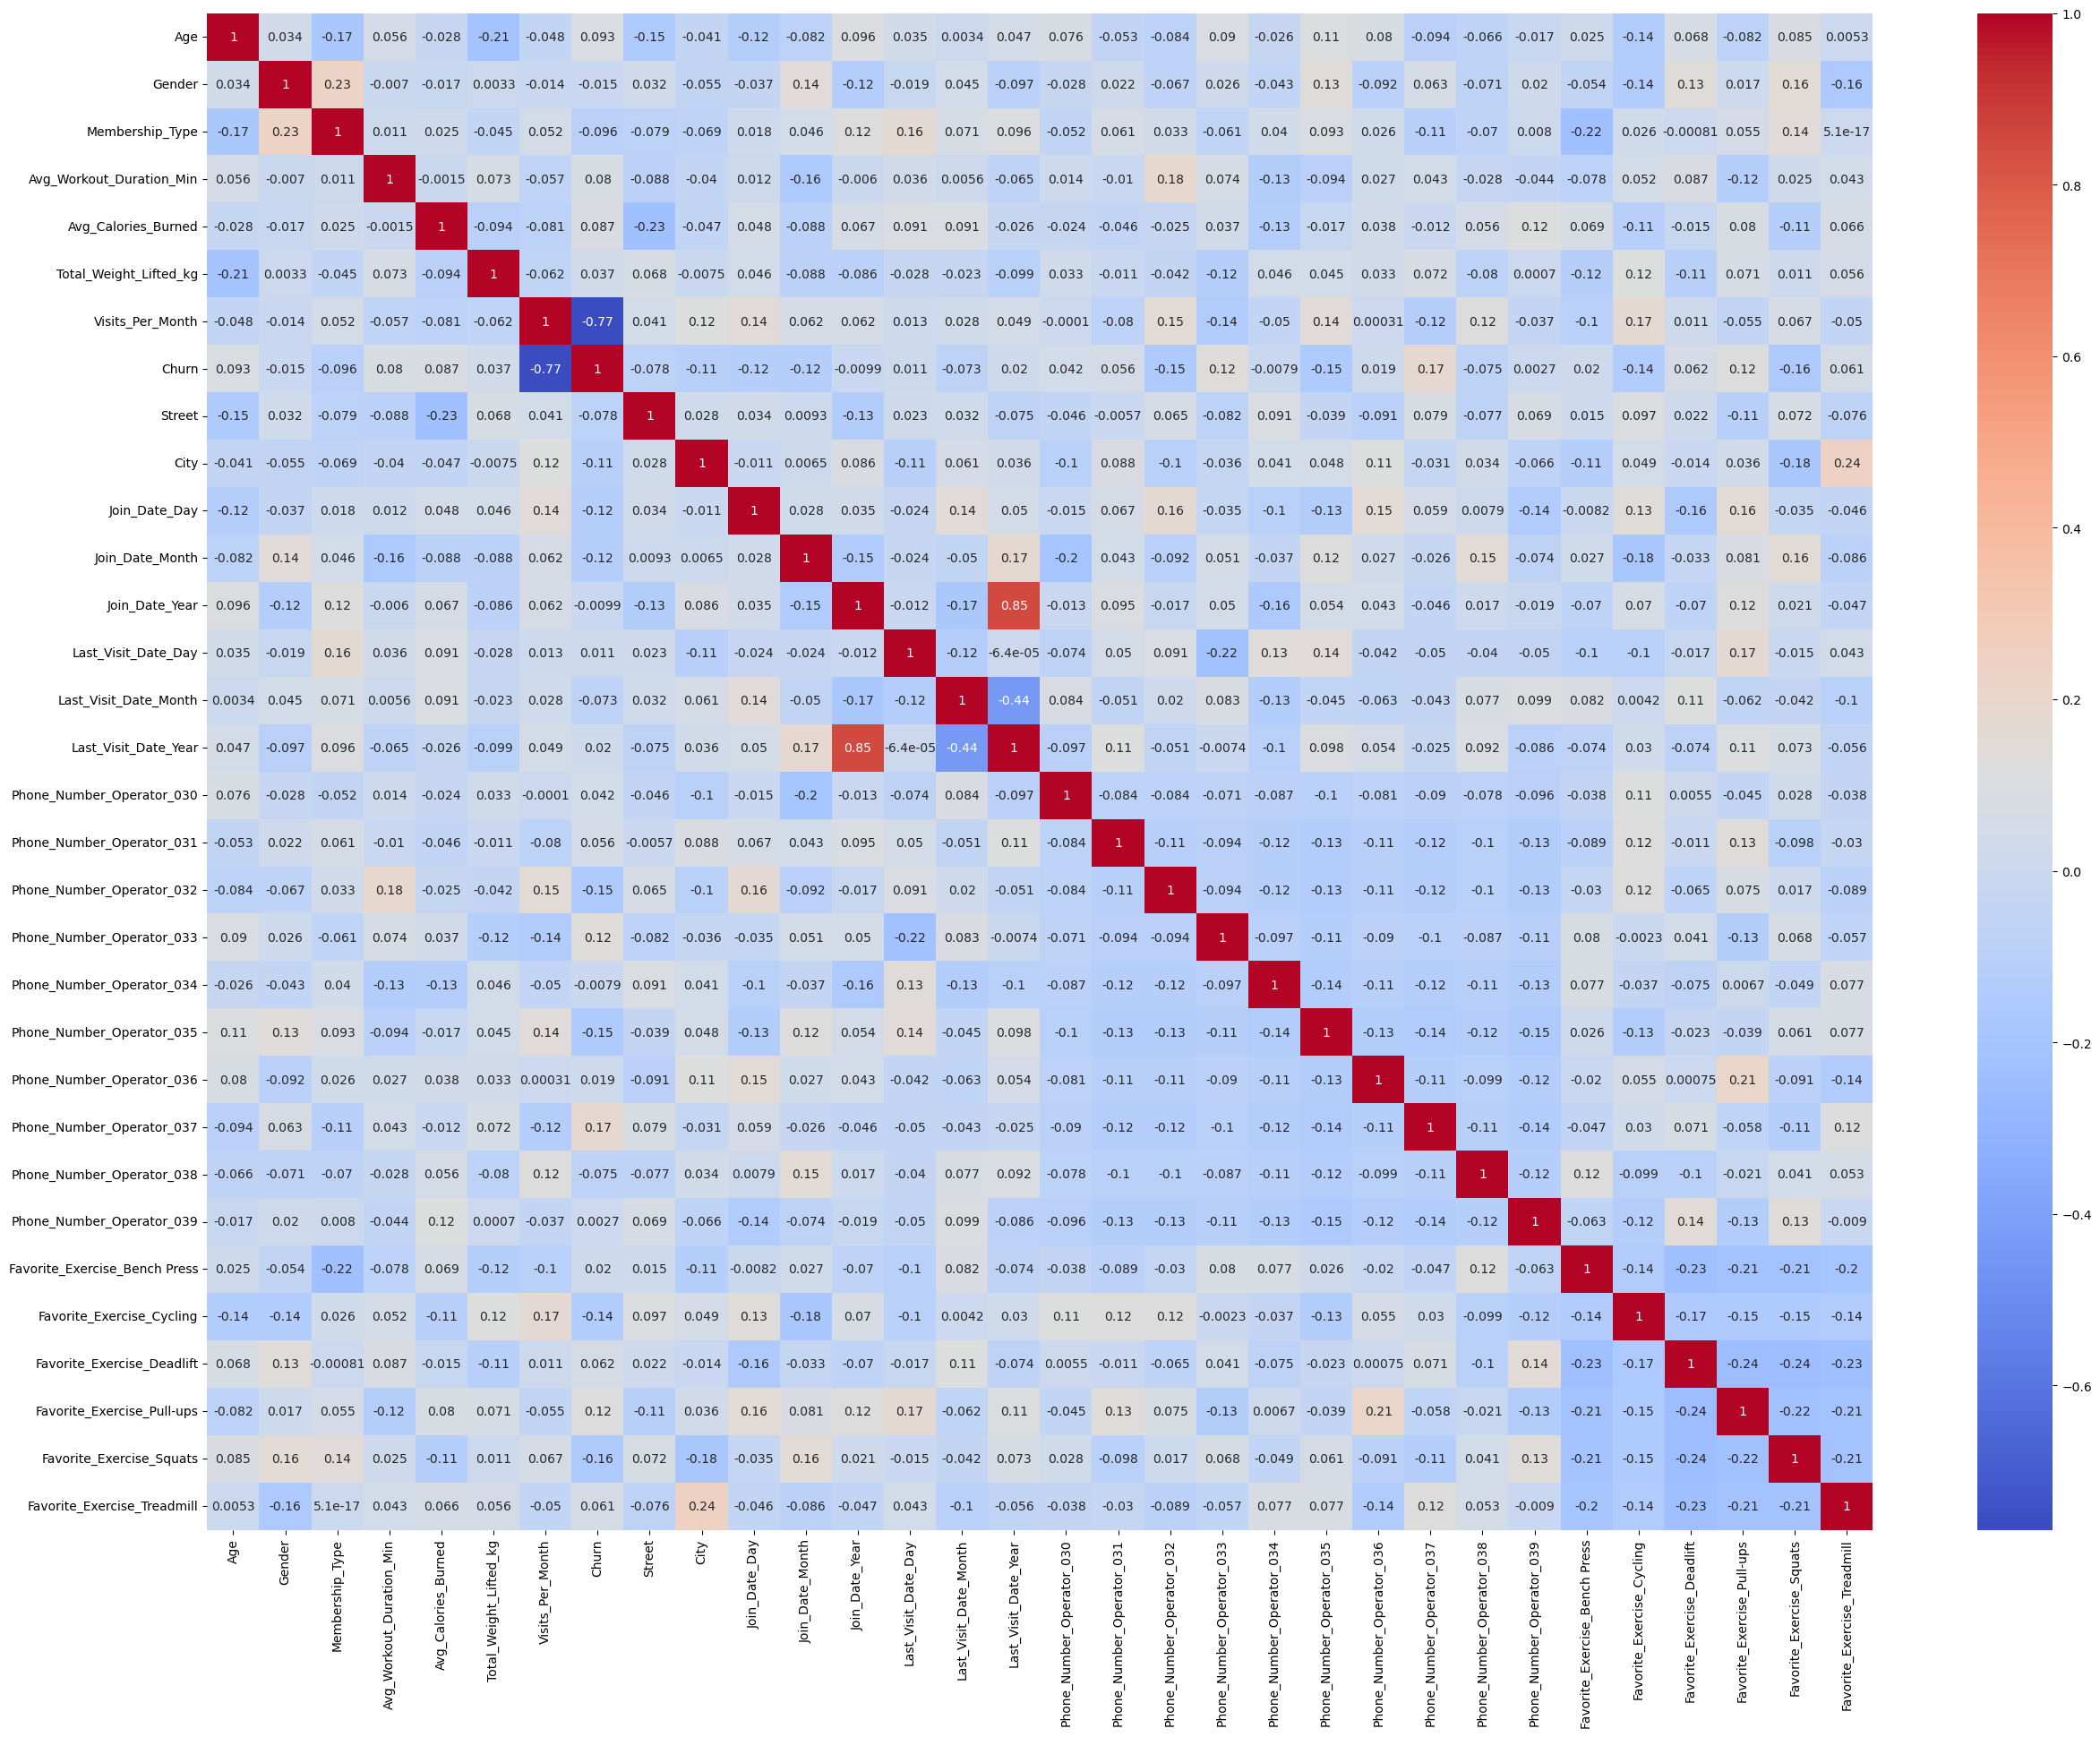

In [50]:
corr = df_encoded[encode_columns].corr()

plt.figure(figsize=(30, 22))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

One quick glance at the large correlation matrix seem to tell us the most dominant factor that affects Churn is the amount of Visits per Month